# Station visualisation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import xarray as xr
import numpy as np
import cartopy.io.shapereader as shapereader
from matplotlib.patches import Rectangle

In [3]:
ltm_df = pd.read_csv('LTM_HKH.csv', names=['name', 'lat', 'lon', 'type'], header=0, index_col=False).dropna()

/tmp/ipykernel_54840/1849554548.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  ltm_df = pd.read_csv('LTM_HKH.csv', names=['name', 'lat', 'lon', 'type'], header=0, index_col=False).dropna()


In [4]:
ltm_df

,name,lat,lon,type
0,Langtang,28.10,85.50,ALL
1,Tanggula,33.00,92.00,ALL
2,Dokriani,30.80,78.80,GLAC
3,Hidden Valley,28.80,83.50,GLAC + PF
4,Khumbu,27.70,86.90,GLAC
5,Chhota Shigri,32.20,77.50,GLAC
6,Tuotuo He,34.00,92.00,HYD + PF
7,South Pullu,34.25,77.62,PF
8,Trambau,27.90,86.50,GLAC
9,Hulu,38.10,99.80,ALL


In [5]:
col_widths = [12, 9, 10, 8, 30, 8, 8]
col_names= ['id', 'lat', 'lon', 'elevation', 'name', 'gsn_flag', 'wmo_id']
ghcnd_df = pd.read_fwf('ghcnd-stations_hma.txt', widths=col_widths, header=None, names=col_names)

In [6]:
# custom modules
import sys
import json
sys.path.append("../..")  # noqa
from load import data_dir
from bcm4rcm.utils.areal_plots import regional_rectangle

In [7]:
# Topography data
top_ds = xr.open_dataset("/data/hpcdata/users/kenzi22/data/Elevation/GMTED2010_data.nc")
top_ds = top_ds.assign_coords({"nlat": top_ds.latitude, "nlon": top_ds.longitude})
top_ds1 = top_ds.sel(nlat=slice(15, 55), nlon=slice(60, 120))
top_ds1["elevation"] = top_ds1.elevation.interpolate_na(dim="nlat", method="linear")

In [8]:
def hillshade(top_ds, azimuth, angle_altitude):

    # Source: http://geoexamples.blogspot.com.br/2014/03/shaded-relief-images-using-gdal-python.html

    z_factor = 0.5
    array = top_ds.elevation.values
    x, y = np.gradient(array)
    x = x / z_factor  # Adjust x gradient
    y = y / z_factor  # Adjust y gradient
    slope = np.pi / 2.0 - np.arctan(np.sqrt(x * x + y * y))
    aspect = np.arctan2(-x, y)
    azimuthrad = azimuth * np.pi / 180.0
    altituderad = angle_altitude * np.pi / 180.0

    shaded = np.sin(altituderad) * np.sin(slope) + np.cos(altituderad) * np.cos(
        slope
    ) * np.cos(azimuthrad - aspect)

    hillshade = 255 * (shaded + 1) / 2

    return hillshade

In [9]:
top_ds1["hillshade"] = (("nlat", "nlon"), hillshade(top_ds1, 315, 80))

In [10]:
# HKH region
hkh_region_path = data_dir + "Shapefiles/hkh/outline.shp"
hkh_region_shape = shapereader.Reader(hkh_region_path)
hkh_region_globe = ccrs.Globe(semimajor_axis=6377276.345, inverse_flattening=300.8017)
hkh_region = ccrs.PlateCarree()

In [11]:
# Filter station dataframe to only include stations within the HKH region

from shapely.geometry import Point, shape

for rec in hkh_region_shape.records():
    hkh_shape = shape(rec.geometry)
    ghcnd_df['geometry'] = ghcnd_df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

new_ghcnd_df = ghcnd_df[ghcnd_df['geometry'].apply(lambda x: hkh_shape.contains(x))]
print(f"Number of GHCND stations within HKH region: {len(new_ghcnd_df)}")

Number of GHCND stations within HKH region: 309


In [12]:
new_ghcnd_df

,id,lat,lon,elevation,name,gsn_flag,wmo_id,geometry
0,AF000040930,35.317,69.017,3366.0,NORTH-SALANG,GSN,40930.0,POINT (69.017 35.317)
2,AFM00040948,34.566,69.212,1791.3,KABUL INTL,NaN,40948.0,POINT (69.212 34.566)
50,CHM00052602,38.833,93.383,2771.0,LENGHU,NaN,52602.0,POINT (93.383 38.833)
52,CHM00052713,37.850,95.367,3174.0,DA-QAIDAM,NaN,52713.0,POINT (95.367 37.85)
53,CHM00052754,37.333,100.133,3302.0,GANGCA,NaN,52754.0,POINT (100.133 37.333)
...,...,...,...,...,...,...,...,...
4470,PKM00041739,26.955,64.133,1002.5,PANJGUR,NaN,41739.0,POINT (64.133 26.955)
4471,PKM00041744,27.833,66.633,1232.0,KHUZDAR,NaN,41744.0,POINT (66.633 27.833)
4524,TI000038930,36.900,68.000,319.0,AJVADZ,NaN,38930.0,POINT (68 36.9)
4536,TI000038954,37.500,71.500,2077.0,KHOROG,GSN,38954.0,POINT (71.5 37.5)


In [13]:
# Create country column for GHCND stations using id prefix

prefix_dict = {
    'IN': 'India',
    'CH': 'China',
    'NP': 'Nepal',
    'AF': 'Afghanistan',
    'PK': 'Pakistan',
    'TI': 'Tajikistan'
}
new_ghcnd_df.loc[:, 'country'] = new_ghcnd_df.loc[:, 'id'].str[:2].map(prefix_dict)
ghcnd_df.loc[:, 'country'] = ghcnd_df.loc[:, 'id'].str[:2].map(prefix_dict)
print(new_ghcnd_df['country'].value_counts())

country
India          246
China           35
Pakistan        21
Tajikistan       3
Afghanistan      2
Nepal            2
Name: count, dtype: int64


/tmp/ipykernel_54840/1370848152.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_ghcnd_df.loc[:, 'country'] = new_ghcnd_df.loc[:, 'id'].str[:2].map(prefix_dict)


In [14]:
colour_map = {
    'India': 'red',
    'China': 'blue',
    'Nepal': 'green',
    'Afghanistan': 'yellow',
    'Pakistan': 'purple',
    'Tajikistan': 'orange'
}

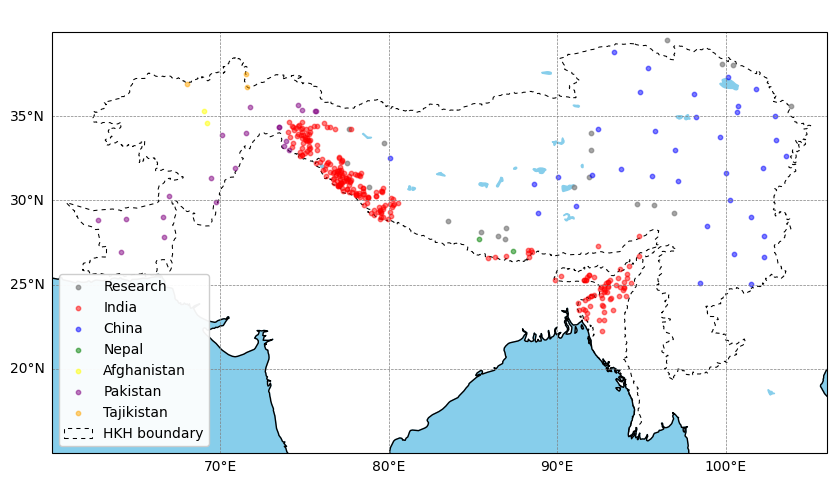

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Cartopy features
ocean_50m = cf.NaturalEarthFeature(
    "physical", "ocean", "50m", edgecolor="face", facecolor="skyblue"
)
lakes_50m = cf.NaturalEarthFeature(
    "physical", "lakes", "50m", edgecolor="skyblue", facecolor="skyblue"
)
# river_50m = cf.NaturalEarthFeature("physical", "rivers_lake_centerlines", "50m", edgecolor="skyblue", facecolor="None")
ax1.add_feature(ocean_50m, zorder=-10)
ax1.add_feature(lakes_50m, label="lakes", zorder=-9)

ltm = ax1.scatter(ltm_df['lon'], ltm_df['lat'], color='Grey', label='Research', transform=ccrs.PlateCarree(), 
            s=10, alpha=0.7)

country_handles = []
for country, color in colour_map.items():
    country_stations = new_ghcnd_df[new_ghcnd_df['country'] == country]
    stations = ax1.scatter(country_stations['lon'], country_stations['lat'], 
                c=color, transform=ccrs.PlateCarree(), label=country, 
                s=10, alpha=0.5)
    country_handles.append(stations)

ax1.add_feature(cf.COASTLINE)
ax1.set_extent([60, 110, 20, 40], crs=ccrs.PlateCarree())

# Mountain boundaries
for rec in hkh_region_shape.records():
    ax1.add_geometries(
        [rec.geometry],
        hkh_region,
        edgecolor="black",
        facecolor="None",
        linestyle=(0, (4, 4)),
        linewidth=0.75,
        zorder=-7,
    )

# Grid
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", color="gray")
gl.top_labels = False
gl.right_labels = False
ax1.set_ylabel(" ")
ax1.set_xlabel(" ")
ax1.set_title(" ")
ax1.set_extent([60, 106, 15, 40], crs=ccrs.PlateCarree())


hkh = Rectangle(
    (0, 0),
    1,
    1,
    fc="None",
    edgecolor="black",
    linewidth=0.75,
    linestyle=(0, (4, 4)),
    label="HKH boundary",
)

ax1.legend(
    handles=[ltm] + country_handles + [hkh], loc="lower left", framealpha=0.95
)

# rasterize negative zorder
ax1.set_rasterization_zorder(0)

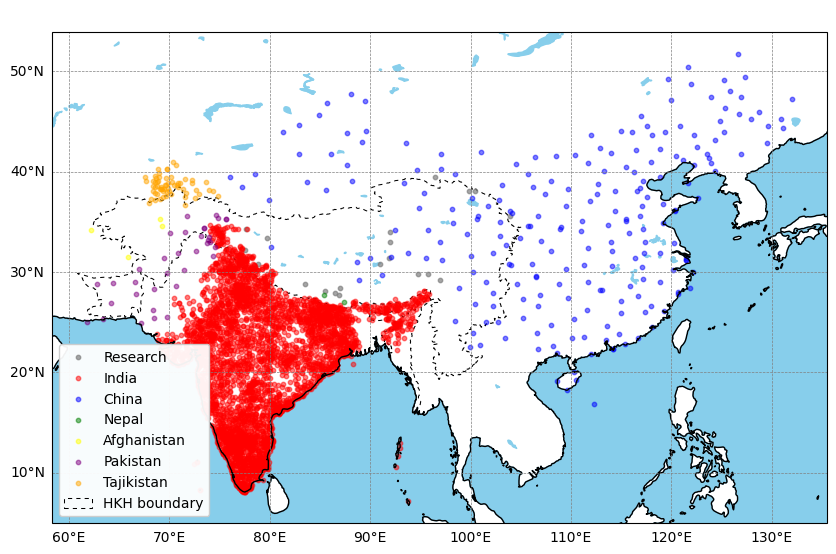

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Cartopy features
ocean_50m = cf.NaturalEarthFeature(
    "physical", "ocean", "50m", edgecolor="face", facecolor="skyblue"
)
lakes_50m = cf.NaturalEarthFeature(
    "physical", "lakes", "50m", edgecolor="skyblue", facecolor="skyblue"
)
# river_50m = cf.NaturalEarthFeature("physical", "rivers_lake_centerlines", "50m", edgecolor="skyblue", facecolor="None")
ax1.add_feature(ocean_50m, zorder=-10)
ax1.add_feature(lakes_50m, label="lakes", zorder=-9)

ltm = ax1.scatter(ltm_df['lon'], ltm_df['lat'], color='Grey', label='Research', transform=ccrs.PlateCarree(), 
            s=10, alpha=0.7)

country_handles = []
for country, color in colour_map.items():
    country_stations = ghcnd_df[ghcnd_df['country'] == country]
    stations = ax1.scatter(country_stations['lon'], country_stations['lat'], 
                c=color, transform=ccrs.PlateCarree(), label=country, 
                s=10, alpha=0.5)
    country_handles.append(stations)

ax1.add_feature(cf.COASTLINE)
#ax1.set_extent([60, 110, 20, 40], crs=ccrs.PlateCarree())

# Mountain boundaries
for rec in hkh_region_shape.records():
    ax1.add_geometries(
        [rec.geometry],
        hkh_region,
        edgecolor="black",
        facecolor="None",
        linestyle=(0, (4, 4)),
        linewidth=0.75,
        zorder=-7,
    )

# Grid
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", color="gray")
gl.top_labels = False
gl.right_labels = False
ax1.set_ylabel(" ")
ax1.set_xlabel(" ")
ax1.set_title(" ")
#ax1.set_extent([60, 105, 10, 40], crs=ccrs.PlateCarree())


hkh = Rectangle(
    (0, 0),
    1,
    1,
    fc="None",
    edgecolor="black",
    linewidth=0.75,
    linestyle=(0, (4, 4)),
    label="HKH boundary",
)

ax1.legend(
    handles=[ltm] + country_handles + [hkh], loc="lower left", framealpha=0.95
)

# rasterize negative zorder
ax1.set_rasterization_zorder(0)

In [ ]:
# Calculate station density using APHRODITE grid

## APRODITE DATASET
ds = xr.open_dataset("/data/hpcdata/users/kenzi22/data/APHRODITE/daily/APHRO_MA_025deg_V1901.1998.nc")

In [47]:
# Create 2D histogram of station locations using APHRODITE grid
res = 0.25
lon_bins = np.arange(60, 105+res, res)
lat_bins = np.arange(20, 40+res, res)


In [45]:
lon_bins.shape, lat_bins.shape

((180,), (80,))

In [48]:
density, lon_edges, lat_edges = np.histogram2d(
    ghcnd_df['lon'], ghcnd_df['lat'], 
    bins=[lon_bins, lat_bins]
)

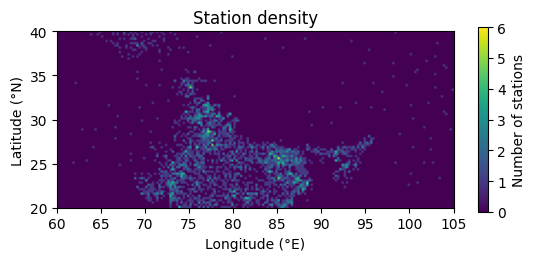

In [60]:
plt.imshow(density.T, origin='lower', extent=[lon_bins[0], lon_bins[-1], lat_bins[0], lat_bins[-1]])
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Station density')
plt.colorbar(label='Number of stations', shrink=0.5)
plt.show()

In [57]:
mask = np.where(density > 0, 1, 0)
mask.shape

(180, 80)

In [51]:
# calculate station density using APHRODITE grid over 32x32 pixel patches
patch_size = 32
mask_patches = []
for i in range(0, mask.shape[0], patch_size):
    for j in range(0, mask.shape[1], patch_size):
        patch = mask[i:i+patch_size, j:j+patch_size]
        mask_patches.append(patch.sum()/(patch_size*patch_size))
mask_patches = np.array(mask_patches)
print("Effective density:", mask_patches.mean())


Effective density: 0.09619140625


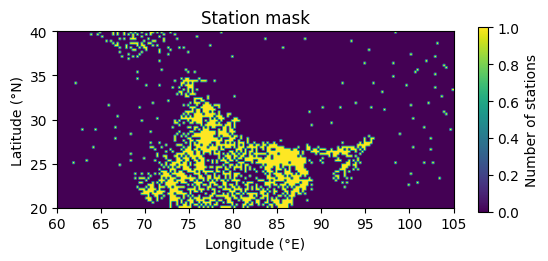

In [59]:
plt.imshow(mask.T, origin='lower', extent=[lon_bins[0], lon_bins[-1], lat_bins[0], lat_bins[-1]], )
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Station mask')
plt.colorbar(label='Number of stations', shrink=0.5)
plt.show()

In [55]:
np.save("hma_station_mask.npy", mask.T)